# 03 - BV vs THINGS RDM Comparison (Included Categories)

This notebook compares representational dissimilarity matrices (RDMs) between BabyView (BV) and THINGS category embeddings.

It:
- Uses the same category inclusion list as other preprint analyses: `data/included_categories.txt`
- Computes category-level cosine-distance RDMs for BV and THINGS
- Runs the comparison for both CLIP and DINOv3 embeddings
- Saves numeric summaries and figures to `analysis/preprint-2026/results` and `analysis/preprint-2026/figures`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr, spearmanr, kendalltau

In [2]:
# Paths and run configuration
ROOT = Path.cwd().resolve().parent.parent
DATA_DIR = ROOT / "data"
ANALYSIS_DIR = ROOT / "analysis"
PREPRINT_DIR = ANALYSIS_DIR / "preprint-2026"
RESULTS_DIR = PREPRINT_DIR / "results"
FIGURES_DIR = PREPRINT_DIR / "figures"

THRESHOLD = "0.27"
# Canonical token used in output filenames to avoid accidental "filtered-0" names.
THRESHOLD_TOKEN = f"{float(THRESHOLD):.2f}"
if THRESHOLD_TOKEN in {"0", "0.0", "0.00"}:
    raise ValueError(f"Suspicious THRESHOLD for filenames: {THRESHOLD}")

COMP_DIR = ANALYSIS_DIR / "vss-2026" / "bv_things_comp_03012026"
INCLUDED_CATEGORIES_TXT = DATA_DIR / "included_categories.txt"
CDI_SEMANTIC_CSV = DATA_DIR / "long_tailed_dist_prop_included_categories.csv"

CDI_SEMANTIC_ORDER = [
    "animals",
    "body_parts",
    "clothing",
    "food_drink",
    "furniture_rooms",
    "household",
    "outside",
    "toys",
    "vehicles",
    "other",
]
CDI_SEMANTIC_COLORS = {
    "animals": "#4DB8A8",
    "body_parts": "#E87A5F",
    "clothing": "#9B7EC8",
    "food_drink": "#E8A54C",
    "furniture_rooms": "#6BAB7A",
    "household": "#D97B9E",
    "outside": "#5B9BD5",
    "people": "#E8C44C",
    "toys": "#B07CC8",
    "vehicles": "#6BA3D5",
    "other": "#8B9A9E",
}

EMBEDDING_PAIRS = {
    "clip": {
        "bv": COMP_DIR / f"bv_clip_filtered_zscored_hierarchical_threshold_{THRESHOLD}_163cats/normalized_filtered_embeddings_alphabetical.csv",
        "things": COMP_DIR / f"things_clip_filtered_zscored_hierarchical_threshold_{THRESHOLD}_163cats/normalized_filtered_embeddings_alphabetical.csv",
    },
    "dinov3": {
        "bv": COMP_DIR / f"bv_dinov3_filtered_zscored_hierarchical_threshold_{THRESHOLD}_163cats/normalized_filtered_embeddings_alphabetical.csv",
        "things": COMP_DIR / f"things_dinov3_filtered_zscored_hierarchical_threshold_{THRESHOLD}_163cats/normalized_filtered_embeddings_alphabetical.csv",
    },
}

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Root: {ROOT}")
print(f"Included categories: {INCLUDED_CATEGORIES_TXT}")
print(f"CDI semantic mapping: {CDI_SEMANTIC_CSV}")
for model_name, files in EMBEDDING_PAIRS.items():
    print(f"[{model_name}] BV: {files['bv']}")
    print(f"[{model_name}] THINGS: {files['things']}")

Root: /home/j7yang/babyview-projects/vss2026/object-detection
Included categories: /home/j7yang/babyview-projects/vss2026/object-detection/data/included_categories.txt
CDI semantic mapping: /home/j7yang/babyview-projects/vss2026/object-detection/data/long_tailed_dist_prop_included_categories.csv
[clip] BV: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/vss-2026/bv_things_comp_03012026/bv_clip_filtered_zscored_hierarchical_threshold_0.27_163cats/normalized_filtered_embeddings_alphabetical.csv
[clip] THINGS: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/vss-2026/bv_things_comp_03012026/things_clip_filtered_zscored_hierarchical_threshold_0.27_163cats/normalized_filtered_embeddings_alphabetical.csv
[dinov3] BV: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/vss-2026/bv_things_comp_03012026/bv_dinov3_filtered_zscored_hierarchical_threshold_0.27_163cats/normalized_filtered_embeddings_alphabetical.csv
[dinov3] THINGS: /home/j7yang/babyvie

In [3]:
def load_embedding_csv(csv_path: Path):
    df = pd.read_csv(csv_path)

    # Handle common category-label column patterns.
    if "category" in df.columns:
        categories = df["category"].astype(str).str.strip().str.lower().tolist()
        embedding_df = df.drop(columns=["category"])
    elif "Unnamed: 0" in df.columns:
        categories = df["Unnamed: 0"].astype(str).str.strip().str.lower().tolist()
        embedding_df = df.drop(columns=["Unnamed: 0"])
    else:
        first_col = df.columns[0]
        first_is_text = pd.api.types.is_object_dtype(df[first_col])
        if first_is_text:
            categories = df[first_col].astype(str).str.strip().str.lower().tolist()
            embedding_df = df.drop(columns=[first_col])
        else:
            categories = [str(c).strip().lower() for c in df.index]
            embedding_df = df.copy()

    # Keep only numeric embedding dimensions.
    embedding_df = embedding_df.select_dtypes(include=[np.number])
    embeddings = embedding_df.to_numpy(dtype=np.float64)

    if len(categories) != embeddings.shape[0]:
        raise ValueError(
            f"Category/embedding row mismatch in {csv_path}: "
            f"{len(categories)} categories vs {embeddings.shape[0]} rows"
        )

    return categories, embeddings


def load_included_categories(txt_path: Path):
    with txt_path.open("r") as f:
        return [line.strip().lower() for line in f if line.strip()]


def load_cdi_semantic_map(csv_path: Path):
    df = pd.read_csv(csv_path)
    required = {"category", "cdi_semantic"}
    if not required.issubset(df.columns):
        raise ValueError(f"Expected columns {required} in {csv_path}")

    mapping = {}
    for _, row in df[["category", "cdi_semantic"]].dropna().iterrows():
        cat = str(row["category"]).strip().lower()
        sem = str(row["cdi_semantic"]).strip().lower()
        mapping[cat] = sem
    return mapping


def align_embeddings_for_included_categories(
    bv_csv: Path,
    things_csv: Path,
    include_txt: Path,
):
    bv_categories, bv_embeddings = load_embedding_csv(bv_csv)
    th_categories, th_embeddings = load_embedding_csv(things_csv)
    included_categories = load_included_categories(include_txt)

    included_set = set(included_categories)
    shared_categories = sorted(set(bv_categories) & set(th_categories) & included_set)

    bv_idx = {c: i for i, c in enumerate(bv_categories)}
    th_idx = {c: i for i, c in enumerate(th_categories)}

    bv_aligned = np.stack([bv_embeddings[bv_idx[c]] for c in shared_categories], axis=0)
    th_aligned = np.stack([th_embeddings[th_idx[c]] for c in shared_categories], axis=0)

    return shared_categories, bv_aligned, th_aligned


def build_semantic_cluster_order(categories: list[str], cdi_semantic_map: dict):
    sem_rank = {s: i for i, s in enumerate(CDI_SEMANTIC_ORDER)}

    annotated = []
    for i, cat in enumerate(categories):
        sem = cdi_semantic_map.get(cat, "other")
        rank = sem_rank.get(sem, sem_rank["other"])
        annotated.append((i, cat, sem, rank))

    # Preserve BV order within each semantic cluster.
    annotated_sorted = sorted(annotated, key=lambda x: (x[3], x[0]))

    reordered_idx = [x[0] for x in annotated_sorted]
    reordered_categories = [x[1] for x in annotated_sorted]
    reordered_semantics = [x[2] for x in annotated_sorted]

    boundaries = []
    prev = None
    for i, sem in enumerate(reordered_semantics):
        if i > 0 and sem != prev:
            boundaries.append(i)
        prev = sem

    return reordered_idx, reordered_categories, reordered_semantics, boundaries


def reorder_rdm(rdm: np.ndarray, reordered_idx: list[int]):
    idx = np.array(reordered_idx, dtype=int)
    return rdm[np.ix_(idx, idx)]


def compute_rdm(embeddings: np.ndarray):
    # Cosine-distance RDM (1 - cosine similarity)
    return squareform(pdist(embeddings, metric="cosine"))


def vectorize_upper_triangle(rdm: np.ndarray):
    iu = np.triu_indices_from(rdm, k=1)
    return rdm[iu]


def compare_rdm_vectors(vec_a: np.ndarray, vec_b: np.ndarray):
    pr, pp = pearsonr(vec_a, vec_b)
    sr, sp = spearmanr(vec_a, vec_b)
    kr, kp = kendalltau(vec_a, vec_b)
    return {
        "pearson_r": float(pr),
        "pearson_p": float(pp),
        "spearman_r": float(sr),
        "spearman_p": float(sp),
        "kendall_r": float(kr),
        "kendall_p": float(kp),
        "mae": float(np.mean(np.abs(vec_a - vec_b))),
        "rmse": float(np.sqrt(np.mean((vec_a - vec_b) ** 2))),
    }

In [4]:
def _draw_semantic_boundaries(ax, boundaries: list[int]):
    for b in boundaries:
        ax.axhline(b - 0.5, color="white", linewidth=0.8, alpha=0.8)
        ax.axvline(b - 0.5, color="white", linewidth=0.8, alpha=0.8)


def plot_rdm_comparison(
    model_name: str,
    categories: list[str],
    semantics: list[str],
    boundaries: list[int],
    bv_rdm: np.ndarray,
    th_rdm: np.ndarray,
    bv_vec: np.ndarray,
    th_vec: np.ndarray,
    metrics: dict,
    out_prefix: Path,
):
    fig = plt.figure(figsize=(18, 6))

    ax1 = fig.add_subplot(1, 3, 1)
    im1 = ax1.imshow(bv_rdm, cmap="viridis", aspect="auto", vmin=0, vmax=2)
    _draw_semantic_boundaries(ax1, boundaries)
    ax1.set_title(f"BV RDM ({model_name.upper()}, CDI-clustered)")
    ax1.set_xticks([])
    ax1.set_yticks([])
    fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

    ax2 = fig.add_subplot(1, 3, 2)
    im2 = ax2.imshow(th_rdm, cmap="viridis", aspect="auto", vmin=0, vmax=2)
    _draw_semantic_boundaries(ax2, boundaries)
    ax2.set_title(f"THINGS RDM ({model_name.upper()}, BV order)")
    ax2.set_xticks([])
    ax2.set_yticks([])
    fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

    ax3 = fig.add_subplot(1, 3, 3)
    ax3.scatter(bv_vec, th_vec, s=14, alpha=0.35)
    lo = min(bv_vec.min(), th_vec.min())
    hi = max(bv_vec.max(), th_vec.max())
    ax3.plot([lo, hi], [lo, hi], "k--", linewidth=1)
    ax3.set_xlabel("BV pairwise dissimilarity")
    ax3.set_ylabel("THINGS pairwise dissimilarity")
    ax3.set_title(
        f"Upper-triangle comparison\n"
        f"Pearson={metrics['pearson_r']:.3f}, Spearman={metrics['spearman_r']:.3f}"
    )

    fig.suptitle(
        f"BV vs THINGS RDM comparison ({model_name.upper()}, n_categories={len(categories)})",
        y=1.02,
    )
    fig.tight_layout()

    png_path = out_prefix.with_suffix(".png")
    pdf_path = out_prefix.with_suffix(".pdf")
    fig.savefig(png_path, dpi=200, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    return png_path, pdf_path

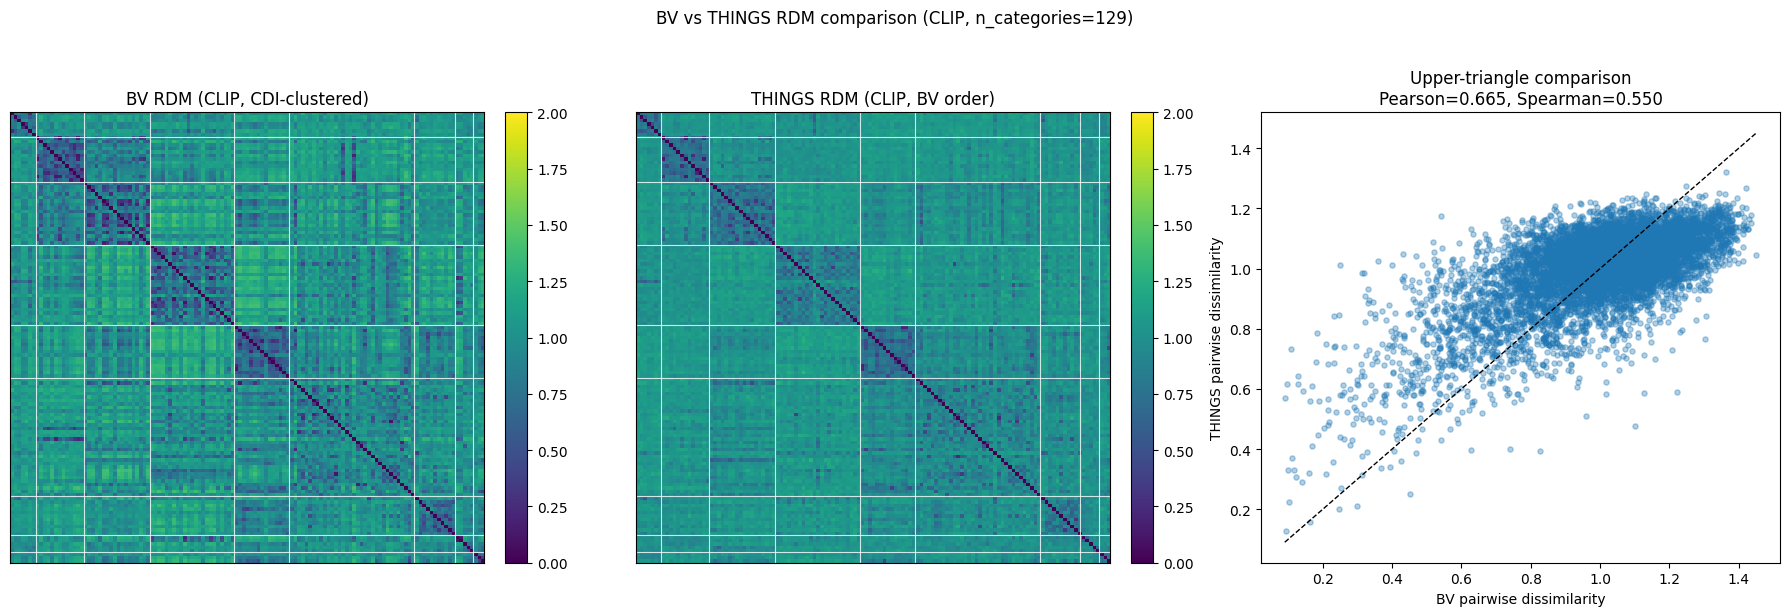

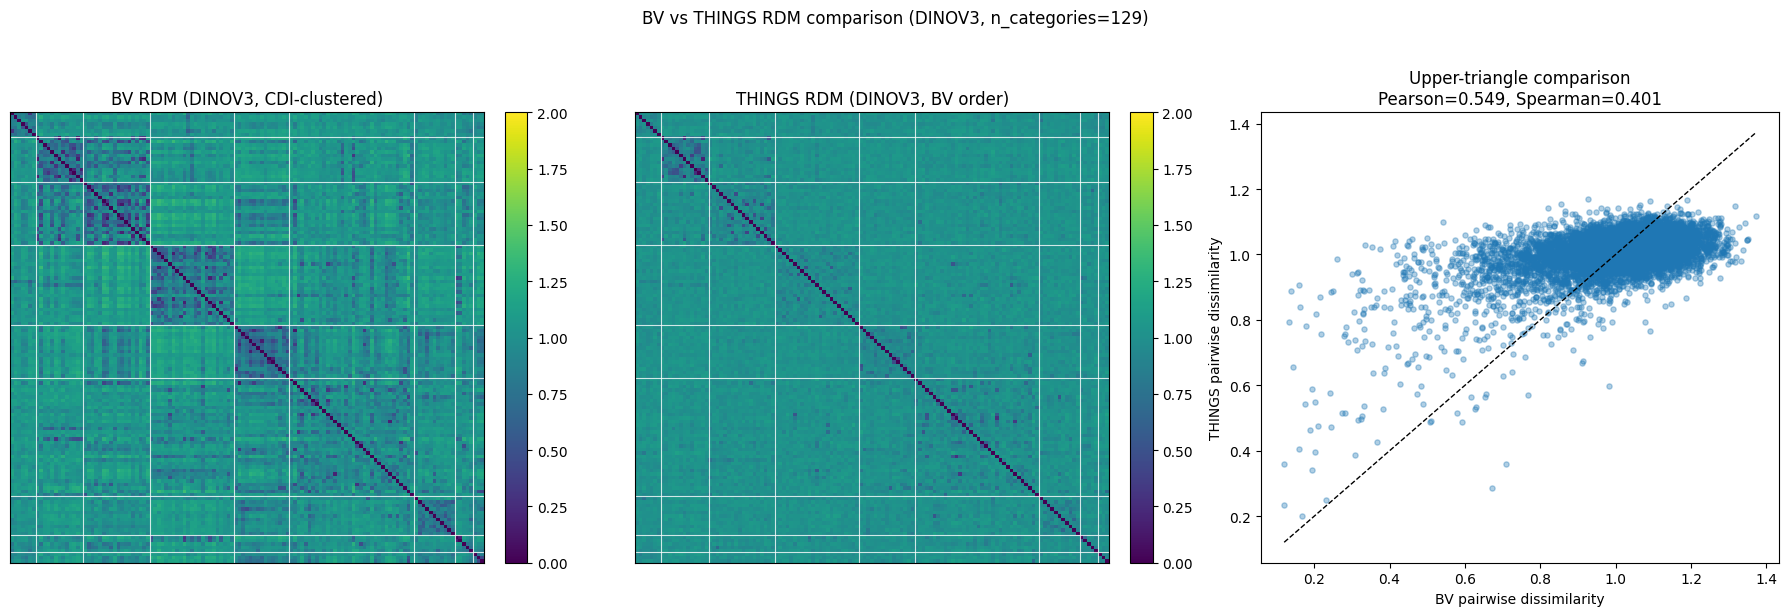

,model,n_categories,n_pairs,n_semantic_clusters,pearson_r,pearson_p,spearman_r,spearman_p,kendall_r,kendall_p,mae,rmse,figure_png,figure_pdf,semantic_counts
0,clip,129,8256,9,0.665206,0.0,0.549640,0.0,0.390351,0.000000e+00,0.122401,0.155299,/home/j7yang/babyview-projects/vss2026/object-...,/home/j7yang/babyview-projects/vss2026/object-...,"{'household': 34, 'food_drink': 23, 'clothing'..."
1,dinov3,129,8256,9,0.548522,0.0,0.400513,0.0,0.275929,2.192322e-309,0.101613,0.136755,/home/j7yang/babyview-projects/vss2026/object-...,/home/j7yang/babyview-projects/vss2026/object-...,"{'household': 34, 'food_drink': 23, 'clothing'..."


In [5]:
summary_rows = []

if not CDI_SEMANTIC_CSV.exists():
    raise FileNotFoundError(f"Missing CDI semantic mapping CSV: {CDI_SEMANTIC_CSV}")
cdi_semantic_map = load_cdi_semantic_map(CDI_SEMANTIC_CSV)

for model_name, paths in EMBEDDING_PAIRS.items():
    bv_csv = paths["bv"]
    th_csv = paths["things"]

    if not INCLUDED_CATEGORIES_TXT.exists():
        raise FileNotFoundError(f"Missing included categories file: {INCLUDED_CATEGORIES_TXT}")
    if not bv_csv.exists():
        raise FileNotFoundError(f"Missing BV embeddings CSV ({model_name}): {bv_csv}")
    if not th_csv.exists():
        raise FileNotFoundError(f"Missing THINGS embeddings CSV ({model_name}): {th_csv}")

    categories, bv_aligned, th_aligned = align_embeddings_for_included_categories(
        bv_csv,
        th_csv,
        INCLUDED_CATEGORIES_TXT,
    )

    bv_rdm = compute_rdm(bv_aligned)
    th_rdm = compute_rdm(th_aligned)

    # Organize by CDI semantic clusters using BV order, then apply same order to THINGS.
    reordered_idx, ordered_categories, ordered_semantics, boundaries = build_semantic_cluster_order(
        categories,
        cdi_semantic_map,
    )
    bv_rdm_ord = reorder_rdm(bv_rdm, reordered_idx)
    th_rdm_ord = reorder_rdm(th_rdm, reordered_idx)

    bv_vec = vectorize_upper_triangle(bv_rdm_ord)
    th_vec = vectorize_upper_triangle(th_rdm_ord)
    metrics = compare_rdm_vectors(bv_vec, th_vec)

    out_prefix = FIGURES_DIR / f"bv_things_rdm_comparison_{model_name}_cdi_clustered_filtered-{THRESHOLD_TOKEN}"
    png_path, pdf_path = plot_rdm_comparison(
        model_name=model_name,
        categories=ordered_categories,
        semantics=ordered_semantics,
        boundaries=boundaries,
        bv_rdm=bv_rdm_ord,
        th_rdm=th_rdm_ord,
        bv_vec=bv_vec,
        th_vec=th_vec,
        metrics=metrics,
        out_prefix=out_prefix,
    )

    semantic_counts = pd.Series(ordered_semantics).value_counts().to_dict()

    row = {
        "model": model_name,
        "n_categories": len(ordered_categories),
        "n_pairs": int(len(bv_vec)),
        "n_semantic_clusters": int(len(set(ordered_semantics))),
        **metrics,
        "figure_png": str(png_path),
        "figure_pdf": str(pdf_path),
        "semantic_counts": str(semantic_counts),
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df

In [6]:
summary_csv = RESULTS_DIR / f"bv_things_rdm_comparison_summary_filtered-{THRESHOLD_TOKEN}.csv"
summary_txt = RESULTS_DIR / f"bv_things_rdm_comparison_summary_filtered-{THRESHOLD_TOKEN}.txt"

summary_df.to_csv(summary_csv, index=False)

lines = [
    "BV vs THINGS RDM comparison summary",
    "",
    f"Included categories file: {INCLUDED_CATEGORIES_TXT}",
    f"Threshold: {THRESHOLD}",
    "",
]

for _, row in summary_df.iterrows():
    lines.extend(
        [
            f"Model: {row['model']}",
            f"  n_categories: {int(row['n_categories'])}",
            f"  n_pairs: {int(row['n_pairs'])}",
            f"  pearson_r: {row['pearson_r']:.6f} (p={row['pearson_p']:.3e})",
            f"  spearman_r: {row['spearman_r']:.6f} (p={row['spearman_p']:.3e})",
            f"  kendall_r: {row['kendall_r']:.6f} (p={row['kendall_p']:.3e})",
            f"  mae: {row['mae']:.6f}",
            f"  rmse: {row['rmse']:.6f}",
            f"  figure_png: {row['figure_png']}",
            f"  figure_pdf: {row['figure_pdf']}",
            "",
        ]
    )

summary_txt.write_text("\n".join(lines))

print(f"Saved CSV: {summary_csv}")
print(f"Saved TXT: {summary_txt}")

Saved CSV: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/results/bv_things_rdm_comparison_summary_filtered-0.27.csv
Saved TXT: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/results/bv_things_rdm_comparison_summary_filtered-0.27.txt


## Notes

- RDM entries are cosine distances (`1 - cosine_similarity`) between category embedding vectors.
- Categories are reordered into CDI semantic clusters (`animals`, `body_parts`, `clothing`, `food_drink`, `furniture_rooms`, `household`, `outside`, `toys`, `vehicles`, `other`).
- The cluster ordering is BV-driven, and THINGS uses the exact same reordered index so the two RDMs are directly comparable.
- The numeric comparison is done on vectorized upper triangles **after** this shared cluster-based reordering.
- If needed, you can change `THRESHOLD` to `"0.28"` (or others) in the config cell and rerun.

## V2: Lower-triangle comparison + labeled clusters + dual ordering

This section adds:
- Lower-triangle RDM vector comparison
- Cluster labels on heatmaps
- Two orderings:
  - **BV-first semantic-clustered** (CDI semantic groups)
  - **THINGS-first data-driven clusters**, then BV reordered to match THINGS order
- Saved order files for both versions

In [7]:
from scipy.cluster.hierarchy import linkage, leaves_list, fcluster

N_THINGS_CLUSTERS = 9


def vectorize_lower_triangle(rdm: np.ndarray):
    il = np.tril_indices_from(rdm, k=-1)
    return rdm[il]


def _boundaries_from_labels(labels: list[str]):
    boundaries = []
    prev = None
    for i, lab in enumerate(labels):
        if i > 0 and lab != prev:
            boundaries.append(i)
        prev = lab
    return boundaries


def _cluster_blocks(labels: list[str]):
    blocks = []
    if not labels:
        return blocks
    start = 0
    cur = labels[0]
    for i in range(1, len(labels)):
        if labels[i] != cur:
            blocks.append((cur, start, i - 1))
            start = i
            cur = labels[i]
    blocks.append((cur, start, len(labels) - 1))
    return blocks


def _plot_heatmap_with_labels(ax, matrix, title, boundaries, block_labels):
    im = ax.imshow(matrix, cmap="viridis", aspect="auto", vmin=0, vmax=2)
    for b in boundaries:
        ax.axhline(b - 0.5, color="white", linewidth=0.8, alpha=0.8)
        ax.axvline(b - 0.5, color="white", linewidth=0.8, alpha=0.8)

    mids = [0.5 * (s + e) for _, s, e in block_labels]
    labs = [lab for lab, _, _ in block_labels]
    ax.set_yticks(mids)
    ax.set_yticklabels(labs, fontsize=8)
    # Color cluster labels by dominant CDI semantic, e.g., "C3 (animals)" -> animals.
    for tick, lab in zip(ax.get_yticklabels(), labs):
        semantic = "other"
        if "(" in lab and ")" in lab:
            semantic = lab.split("(", 1)[1].split(")", 1)[0].strip()
        tick.set_color(CDI_SEMANTIC_COLORS.get(semantic, CDI_SEMANTIC_COLORS["other"]))
    ax.tick_params(axis="y", length=0)
    ax.set_xticks([])
    ax.set_title(title)
    return im


def build_things_cluster_order(categories: list[str], things_rdm: np.ndarray, cdi_semantic_map: dict, n_clusters: int = 9):
    condensed = squareform(things_rdm, checks=False)
    Z = linkage(condensed, method="average")

    order_idx = leaves_list(Z).astype(int).tolist()
    cluster_ids = fcluster(Z, t=n_clusters, criterion="maxclust")

    ordered_categories = [categories[i] for i in order_idx]
    ordered_cluster_ids = [int(cluster_ids[i]) for i in order_idx]
    ordered_semantics = [cdi_semantic_map.get(c, "other") for c in ordered_categories]

    # Human-readable labels: Ck (dominant_semantic)
    cluster_to_sem = {}
    for cid in sorted(set(cluster_ids)):
        cats = [categories[i] for i in range(len(categories)) if int(cluster_ids[i]) == int(cid)]
        sems = [cdi_semantic_map.get(c, "other") for c in cats]
        dominant = pd.Series(sems).value_counts().index[0] if len(sems) else "other"
        cluster_to_sem[int(cid)] = dominant

    ordered_cluster_labels = [f"C{cid} ({cluster_to_sem[cid]})" for cid in ordered_cluster_ids]
    boundaries = _boundaries_from_labels(ordered_cluster_labels)

    return {
        "order_idx": order_idx,
        "ordered_categories": ordered_categories,
        "ordered_semantics": ordered_semantics,
        "ordered_cluster_ids": ordered_cluster_ids,
        "ordered_cluster_labels": ordered_cluster_labels,
        "boundaries": boundaries,
    }


def plot_ordered_rdms(
    model_name: str,
    version_name: str,
    bv_rdm_ord: np.ndarray,
    th_rdm_ord: np.ndarray,
    bv_vec: np.ndarray,
    th_vec: np.ndarray,
    metrics: dict,
    boundaries: list[int],
    block_labels: list[tuple],
    out_prefix: Path,
):
    fig = plt.figure(figsize=(19, 6))

    ax1 = fig.add_subplot(1, 3, 1)
    im1 = _plot_heatmap_with_labels(
        ax1,
        bv_rdm_ord,
        f"BV RDM ({model_name.upper()}, {version_name})",
        boundaries,
        block_labels,
    )
    fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

    ax2 = fig.add_subplot(1, 3, 2)
    im2 = _plot_heatmap_with_labels(
        ax2,
        th_rdm_ord,
        f"THINGS RDM ({model_name.upper()}, same order)",
        boundaries,
        block_labels,
    )
    fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

    ax3 = fig.add_subplot(1, 3, 3)
    ax3.scatter(bv_vec, th_vec, s=14, alpha=0.35)
    lo = min(bv_vec.min(), th_vec.min())
    hi = max(bv_vec.max(), th_vec.max())
    ax3.plot([lo, hi], [lo, hi], "k--", linewidth=1)
    ax3.set_xlabel("BV lower-triangle dissimilarity")
    ax3.set_ylabel("THINGS lower-triangle dissimilarity")
    ax3.set_title(
        f"Lower-triangle comparison\n"
        f"Pearson={metrics['pearson_r']:.3f}, Spearman={metrics['spearman_r']:.3f}"
    )

    fig.tight_layout()
    png_path = out_prefix.with_suffix(".png")
    pdf_path = out_prefix.with_suffix(".pdf")
    fig.savefig(png_path, dpi=220, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    return png_path, pdf_path

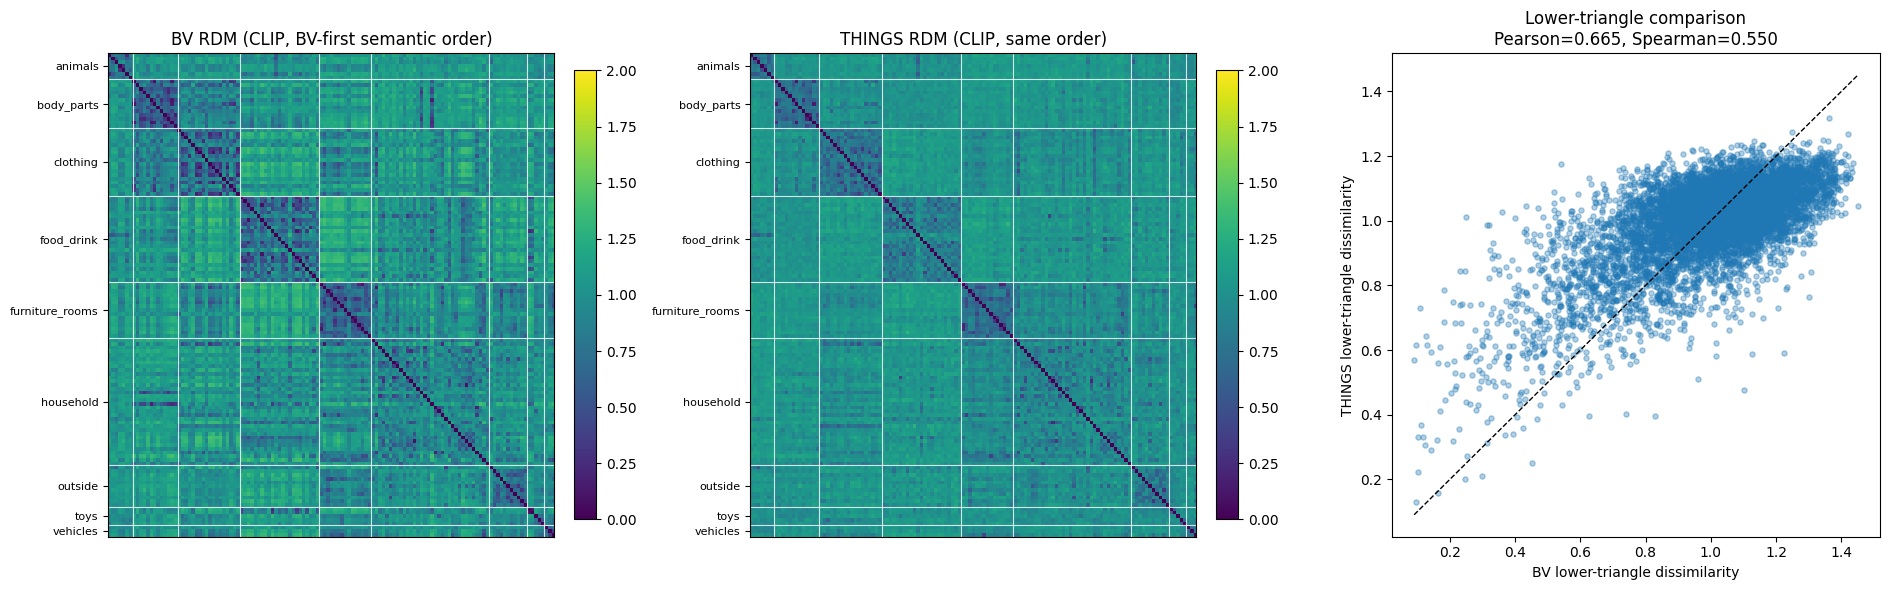

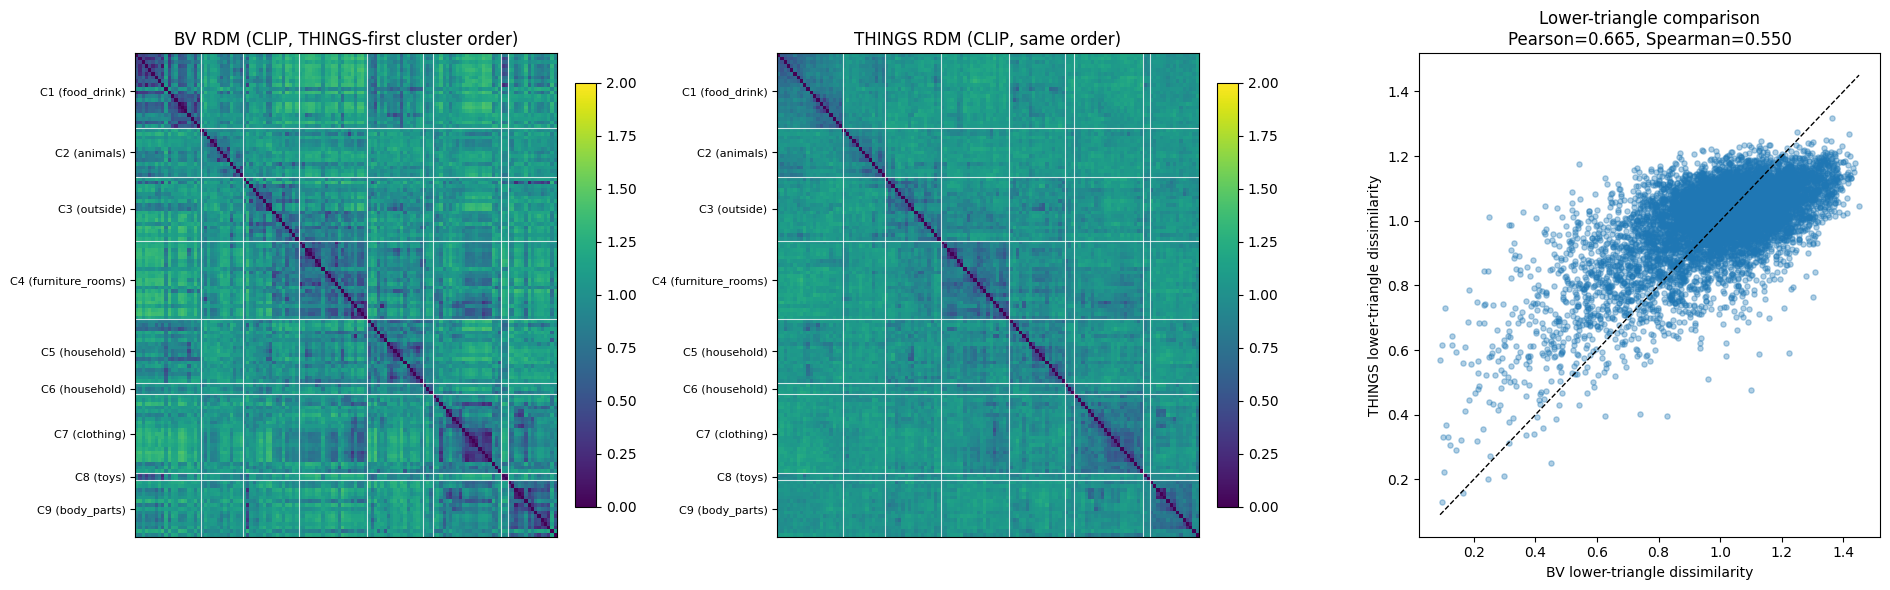

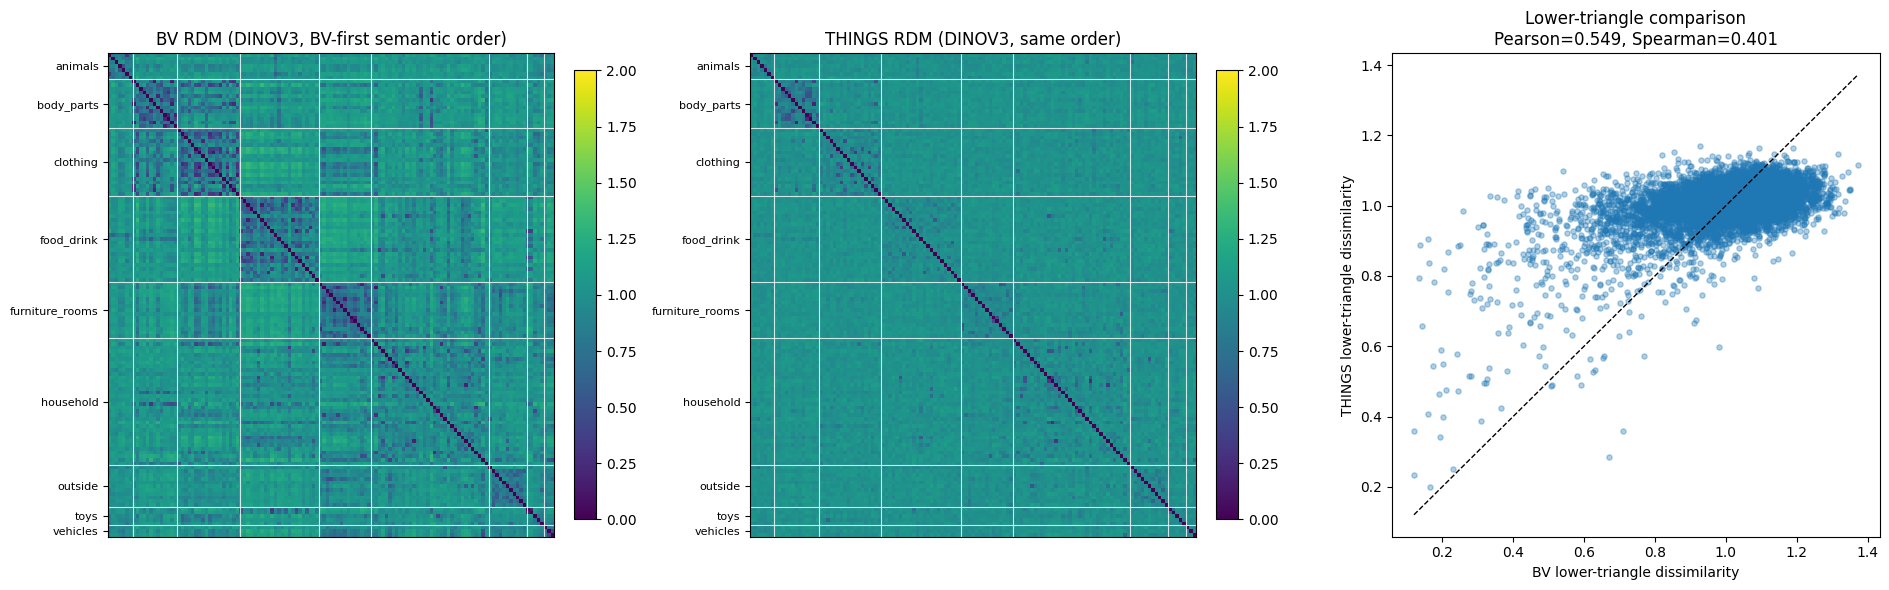

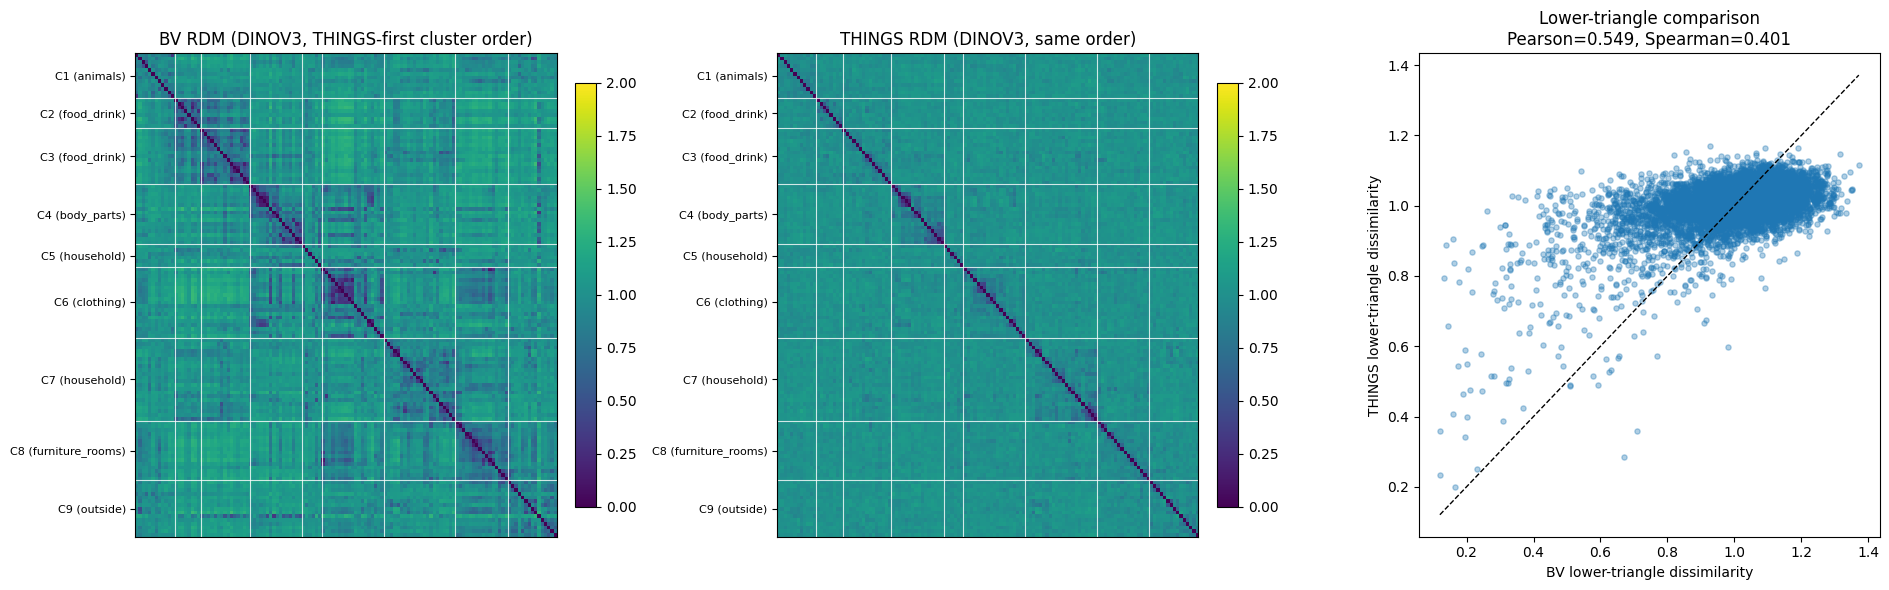

Saved summary CSV: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/results/bv_things_rdm_comparison_summary_v2_lowertri_filtered-0.27.csv
Saved summary TXT: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/results/bv_things_rdm_comparison_summary_v2_lowertri_filtered-0.27.txt


,model,ordering,n_categories,n_pairs,pearson_r,pearson_p,spearman_r,spearman_p,kendall_r,kendall_p,mae,rmse,figure_png,figure_pdf,order_csv
0,clip,bv_first_semantic,129,8256,0.665206,0.0,0.549640,0.0,0.390351,0.000000e+00,0.122401,0.155299,/home/j7yang/babyview-projects/vss2026/object-...,/home/j7yang/babyview-projects/vss2026/object-...,/home/j7yang/babyview-projects/vss2026/object-...
1,clip,things_first_cluster,129,8256,0.665206,0.0,0.549640,0.0,0.390351,0.000000e+00,0.122401,0.155299,/home/j7yang/babyview-projects/vss2026/object-...,/home/j7yang/babyview-projects/vss2026/object-...,/home/j7yang/babyview-projects/vss2026/object-...
2,dinov3,bv_first_semantic,129,8256,0.548522,0.0,0.400513,0.0,0.275929,2.192322e-309,0.101613,0.136755,/home/j7yang/babyview-projects/vss2026/object-...,/home/j7yang/babyview-projects/vss2026/object-...,/home/j7yang/babyview-projects/vss2026/object-...
3,dinov3,things_first_cluster,129,8256,0.548522,0.0,0.400513,0.0,0.275929,2.192322e-309,0.101613,0.136755,/home/j7yang/babyview-projects/vss2026/object-...,/home/j7yang/babyview-projects/vss2026/object-...,/home/j7yang/babyview-projects/vss2026/object-...


In [8]:
summary_rows_v2 = []

if not CDI_SEMANTIC_CSV.exists():
    raise FileNotFoundError(f"Missing CDI semantic mapping CSV: {CDI_SEMANTIC_CSV}")
cdi_semantic_map = load_cdi_semantic_map(CDI_SEMANTIC_CSV)

for model_name, paths in EMBEDDING_PAIRS.items():
    bv_csv = paths["bv"]
    th_csv = paths["things"]

    categories, bv_aligned, th_aligned = align_embeddings_for_included_categories(
        bv_csv,
        th_csv,
        INCLUDED_CATEGORIES_TXT,
    )

    bv_rdm = compute_rdm(bv_aligned)
    th_rdm = compute_rdm(th_aligned)

    # ------------------------------
    # A) BV-first semantic order
    # ------------------------------
    idx_bv, cats_bv, sems_bv, boundaries_bv = build_semantic_cluster_order(categories, cdi_semantic_map)
    bv_rdm_bv = reorder_rdm(bv_rdm, idx_bv)
    th_rdm_bv = reorder_rdm(th_rdm, idx_bv)

    bv_vec_bv = vectorize_lower_triangle(bv_rdm_bv)
    th_vec_bv = vectorize_lower_triangle(th_rdm_bv)
    metrics_bv = compare_rdm_vectors(bv_vec_bv, th_vec_bv)

    block_labels_bv = _cluster_blocks(sems_bv)
    out_prefix_bv = FIGURES_DIR / f"bv_things_rdm_comparison_{model_name}_bv_semantic_lowertri_filtered-{THRESHOLD_TOKEN}"
    fig_bv_png, fig_bv_pdf = plot_ordered_rdms(
        model_name=model_name,
        version_name="BV-first semantic order",
        bv_rdm_ord=bv_rdm_bv,
        th_rdm_ord=th_rdm_bv,
        bv_vec=bv_vec_bv,
        th_vec=th_vec_bv,
        metrics=metrics_bv,
        boundaries=boundaries_bv,
        block_labels=block_labels_bv,
        out_prefix=out_prefix_bv,
    )

    order_bv_df = pd.DataFrame(
        {
            "position": np.arange(len(cats_bv), dtype=int),
            "category": cats_bv,
            "cdi_semantic": sems_bv,
            "source_order": "bv_first_semantic",
        }
    )
    order_bv_csv = RESULTS_DIR / f"bv_things_rdm_order_bv_semantic_{model_name}_filtered-{THRESHOLD_TOKEN}.csv"
    order_bv_df.to_csv(order_bv_csv, index=False)

    summary_rows_v2.append(
        {
            "model": model_name,
            "ordering": "bv_first_semantic",
            "n_categories": len(cats_bv),
            "n_pairs": int(len(bv_vec_bv)),
            **metrics_bv,
            "figure_png": str(fig_bv_png),
            "figure_pdf": str(fig_bv_pdf),
            "order_csv": str(order_bv_csv),
        }
    )

    # ------------------------------
    # B) THINGS-first cluster order
    # ------------------------------
    th_order = build_things_cluster_order(
        categories=categories,
        things_rdm=th_rdm,
        cdi_semantic_map=cdi_semantic_map,
        n_clusters=N_THINGS_CLUSTERS,
    )

    idx_th = th_order["order_idx"]
    cats_th = th_order["ordered_categories"]
    sems_th = th_order["ordered_semantics"]
    cluster_ids_th = th_order["ordered_cluster_ids"]
    cluster_labels_th = th_order["ordered_cluster_labels"]
    boundaries_th = th_order["boundaries"]

    bv_rdm_th = reorder_rdm(bv_rdm, idx_th)
    th_rdm_th = reorder_rdm(th_rdm, idx_th)

    bv_vec_th = vectorize_lower_triangle(bv_rdm_th)
    th_vec_th = vectorize_lower_triangle(th_rdm_th)
    metrics_th = compare_rdm_vectors(bv_vec_th, th_vec_th)

    block_labels_th = _cluster_blocks(cluster_labels_th)
    out_prefix_th = FIGURES_DIR / f"bv_things_rdm_comparison_{model_name}_things_cluster_lowertri_filtered-{THRESHOLD_TOKEN}"
    fig_th_png, fig_th_pdf = plot_ordered_rdms(
        model_name=model_name,
        version_name="THINGS-first cluster order",
        bv_rdm_ord=bv_rdm_th,
        th_rdm_ord=th_rdm_th,
        bv_vec=bv_vec_th,
        th_vec=th_vec_th,
        metrics=metrics_th,
        boundaries=boundaries_th,
        block_labels=block_labels_th,
        out_prefix=out_prefix_th,
    )

    order_th_df = pd.DataFrame(
        {
            "position": np.arange(len(cats_th), dtype=int),
            "category": cats_th,
            "cdi_semantic": sems_th,
            "things_cluster_id": cluster_ids_th,
            "things_cluster_label": cluster_labels_th,
            "source_order": "things_first_cluster",
        }
    )
    order_th_csv = RESULTS_DIR / f"bv_things_rdm_order_things_cluster_{model_name}_filtered-{THRESHOLD_TOKEN}.csv"
    order_th_df.to_csv(order_th_csv, index=False)

    summary_rows_v2.append(
        {
            "model": model_name,
            "ordering": "things_first_cluster",
            "n_categories": len(cats_th),
            "n_pairs": int(len(bv_vec_th)),
            **metrics_th,
            "figure_png": str(fig_th_png),
            "figure_pdf": str(fig_th_pdf),
            "order_csv": str(order_th_csv),
        }
    )

summary_v2_df = pd.DataFrame(summary_rows_v2)
summary_v2_csv = RESULTS_DIR / f"bv_things_rdm_comparison_summary_v2_lowertri_filtered-{THRESHOLD_TOKEN}.csv"
summary_v2_txt = RESULTS_DIR / f"bv_things_rdm_comparison_summary_v2_lowertri_filtered-{THRESHOLD_TOKEN}.txt"

summary_v2_df.to_csv(summary_v2_csv, index=False)

lines = [
    "BV vs THINGS RDM comparison summary (v2)",
    "",
    f"Included categories file: {INCLUDED_CATEGORIES_TXT}",
    f"CDI semantic mapping: {CDI_SEMANTIC_CSV}",
    f"Threshold: {THRESHOLD}",
    f"N_THINGS_CLUSTERS: {N_THINGS_CLUSTERS}",
    "",
]

for _, row in summary_v2_df.iterrows():
    lines.extend(
        [
            f"Model: {row['model']} | Ordering: {row['ordering']}",
            f"  n_categories: {int(row['n_categories'])}",
            f"  n_pairs: {int(row['n_pairs'])}",
            f"  pearson_r: {row['pearson_r']:.6f} (p={row['pearson_p']:.3e})",
            f"  spearman_r: {row['spearman_r']:.6f} (p={row['spearman_p']:.3e})",
            f"  kendall_r: {row['kendall_r']:.6f} (p={row['kendall_p']:.3e})",
            f"  mae: {row['mae']:.6f}",
            f"  rmse: {row['rmse']:.6f}",
            f"  figure_png: {row['figure_png']}",
            f"  figure_pdf: {row['figure_pdf']}",
            f"  order_csv: {row['order_csv']}",
            "",
        ]
    )

summary_v2_txt.write_text("\n".join(lines))
print(f"Saved summary CSV: {summary_v2_csv}")
print(f"Saved summary TXT: {summary_v2_txt}")
summary_v2_df

## Cluster labeling

- **BV-first semantic order**: cluster labels are CDI semantic names from `cdi_semantic`.
- **THINGS-first cluster order**: clusters are discovered from THINGS RDM via hierarchical clustering (`average` linkage), then labeled as `Ck (dominant_semantic)` where `dominant_semantic` is the most frequent CDI semantic label in that discovered cluster.
- You can change `N_THINGS_CLUSTERS` in the V2 helper cell.

## Cross-model correlation within BV and THINGS

This section computes RDM correlations between:
- **BV CLIP** vs **BV DINOv3**
- **THINGS CLIP** vs **THINGS DINOv3**

using the same included categories and lower-triangle vectorization.

In [9]:
# Build a common category set across all four embedding tables.
clip_bv_cats, clip_bv_emb = load_embedding_csv(EMBEDDING_PAIRS["clip"]["bv"])
clip_th_cats, clip_th_emb = load_embedding_csv(EMBEDDING_PAIRS["clip"]["things"])
dino_bv_cats, dino_bv_emb = load_embedding_csv(EMBEDDING_PAIRS["dinov3"]["bv"])
dino_th_cats, dino_th_emb = load_embedding_csv(EMBEDDING_PAIRS["dinov3"]["things"])

included = set(load_included_categories(INCLUDED_CATEGORIES_TXT))
common_cats = sorted(
    set(clip_bv_cats)
    & set(clip_th_cats)
    & set(dino_bv_cats)
    & set(dino_th_cats)
    & included
)

clip_bv_idx = {c: i for i, c in enumerate(clip_bv_cats)}
clip_th_idx = {c: i for i, c in enumerate(clip_th_cats)}
dino_bv_idx = {c: i for i, c in enumerate(dino_bv_cats)}
dino_th_idx = {c: i for i, c in enumerate(dino_th_cats)}

clip_bv_aligned = np.stack([clip_bv_emb[clip_bv_idx[c]] for c in common_cats], axis=0)
clip_th_aligned = np.stack([clip_th_emb[clip_th_idx[c]] for c in common_cats], axis=0)
dino_bv_aligned = np.stack([dino_bv_emb[dino_bv_idx[c]] for c in common_cats], axis=0)
dino_th_aligned = np.stack([dino_th_emb[dino_th_idx[c]] for c in common_cats], axis=0)

# RDMs (cosine distance), then lower-triangle vectors.
rdm_clip_bv = compute_rdm(clip_bv_aligned)
rdm_dino_bv = compute_rdm(dino_bv_aligned)
rdm_clip_th = compute_rdm(clip_th_aligned)
rdm_dino_th = compute_rdm(dino_th_aligned)

vec_clip_bv = vectorize_lower_triangle(rdm_clip_bv)
vec_dino_bv = vectorize_lower_triangle(rdm_dino_bv)
vec_clip_th = vectorize_lower_triangle(rdm_clip_th)
vec_dino_th = vectorize_lower_triangle(rdm_dino_th)

bv_cross_model = compare_rdm_vectors(vec_clip_bv, vec_dino_bv)
things_cross_model = compare_rdm_vectors(vec_clip_th, vec_dino_th)

cross_model_df = pd.DataFrame(
    [
        {
            "dataset": "bv",
            "model_a": "clip",
            "model_b": "dinov3",
            "n_categories": len(common_cats),
            "n_pairs": int(len(vec_clip_bv)),
            **bv_cross_model,
        },
        {
            "dataset": "things",
            "model_a": "clip",
            "model_b": "dinov3",
            "n_categories": len(common_cats),
            "n_pairs": int(len(vec_clip_th)),
            **things_cross_model,
        },
    ]
)

cross_model_csv = RESULTS_DIR / f"bv_things_cross_model_rdm_correlations_filtered-{THRESHOLD_TOKEN}.csv"
cross_model_txt = RESULTS_DIR / f"bv_things_cross_model_rdm_correlations_filtered-{THRESHOLD_TOKEN}.txt"

cross_model_df.to_csv(cross_model_csv, index=False)

lines = [
    "Cross-model RDM correlations (lower triangle)",
    "",
    f"Included categories file: {INCLUDED_CATEGORIES_TXT}",
    f"Threshold: {THRESHOLD}",
    f"n_common_categories: {len(common_cats)}",
    "",
]
for _, row in cross_model_df.iterrows():
    lines.extend(
        [
            f"Dataset: {row['dataset']} ({row['model_a']} vs {row['model_b']})",
            f"  n_pairs: {int(row['n_pairs'])}",
            f"  pearson_r: {row['pearson_r']:.6f} (p={row['pearson_p']:.3e})",
            f"  spearman_r: {row['spearman_r']:.6f} (p={row['spearman_p']:.3e})",
            f"  kendall_r: {row['kendall_r']:.6f} (p={row['kendall_p']:.3e})",
            f"  mae: {row['mae']:.6f}",
            f"  rmse: {row['rmse']:.6f}",
            "",
        ]
    )

cross_model_txt.write_text("\n".join(lines))

print(f"Saved CSV: {cross_model_csv}")
print(f"Saved TXT: {cross_model_txt}")
cross_model_df

Saved CSV: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/results/bv_things_cross_model_rdm_correlations_filtered-0.27.csv
Saved TXT: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/results/bv_things_cross_model_rdm_correlations_filtered-0.27.txt


,dataset,model_a,model_b,n_categories,n_pairs,pearson_r,pearson_p,spearman_r,spearman_p,kendall_r,kendall_p,mae,rmse
0,bv,clip,dinov3,129,8256,0.907101,0.0,0.877460,0.0,0.698944,0.0,0.072103,0.091344
1,things,clip,dinov3,129,8256,0.677315,0.0,0.483957,0.0,0.338765,0.0,0.074884,0.097272


## Per-semantic-cluster cross-model correlations

This computes CLIP-vs-DINOv3 RDM correlation **within each CDI semantic cluster** for:
- BV
- THINGS

Using lower-triangle vectorization on the sub-RDM for each cluster.

In [10]:
# Reuse common_cats and aligned embeddings from the cross-model cell when available.
# Fallback: rebuild if this cell is run independently.
if "common_cats" not in globals() or "clip_bv_aligned" not in globals():
    clip_bv_cats, clip_bv_emb = load_embedding_csv(EMBEDDING_PAIRS["clip"]["bv"])
    clip_th_cats, clip_th_emb = load_embedding_csv(EMBEDDING_PAIRS["clip"]["things"])
    dino_bv_cats, dino_bv_emb = load_embedding_csv(EMBEDDING_PAIRS["dinov3"]["bv"])
    dino_th_cats, dino_th_emb = load_embedding_csv(EMBEDDING_PAIRS["dinov3"]["things"])

    included = set(load_included_categories(INCLUDED_CATEGORIES_TXT))
    common_cats = sorted(
        set(clip_bv_cats)
        & set(clip_th_cats)
        & set(dino_bv_cats)
        & set(dino_th_cats)
        & included
    )

    clip_bv_idx = {c: i for i, c in enumerate(clip_bv_cats)}
    clip_th_idx = {c: i for i, c in enumerate(clip_th_cats)}
    dino_bv_idx = {c: i for i, c in enumerate(dino_bv_cats)}
    dino_th_idx = {c: i for i, c in enumerate(dino_th_cats)}

    clip_bv_aligned = np.stack([clip_bv_emb[clip_bv_idx[c]] for c in common_cats], axis=0)
    clip_th_aligned = np.stack([clip_th_emb[clip_th_idx[c]] for c in common_cats], axis=0)
    dino_bv_aligned = np.stack([dino_bv_emb[dino_bv_idx[c]] for c in common_cats], axis=0)
    dino_th_aligned = np.stack([dino_th_emb[dino_th_idx[c]] for c in common_cats], axis=0)

if "cdi_semantic_map" not in globals():
    cdi_semantic_map = load_cdi_semantic_map(CDI_SEMANTIC_CSV)

sem_to_indices = {}
for i, cat in enumerate(common_cats):
    sem = cdi_semantic_map.get(cat, "other")
    sem_to_indices.setdefault(sem, []).append(i)

rows = []

for sem in CDI_SEMANTIC_ORDER:
    if sem not in sem_to_indices:
        continue

    idx = sem_to_indices[sem]
    if len(idx) < 3:
        # Need at least 3 categories for a meaningful lower-triangle vector.
        continue

    clip_bv_sub = clip_bv_aligned[idx, :]
    dino_bv_sub = dino_bv_aligned[idx, :]
    clip_th_sub = clip_th_aligned[idx, :]
    dino_th_sub = dino_th_aligned[idx, :]

    vec_clip_bv_sub = vectorize_lower_triangle(compute_rdm(clip_bv_sub))
    vec_dino_bv_sub = vectorize_lower_triangle(compute_rdm(dino_bv_sub))
    vec_clip_th_sub = vectorize_lower_triangle(compute_rdm(clip_th_sub))
    vec_dino_th_sub = vectorize_lower_triangle(compute_rdm(dino_th_sub))

    bv_stats = compare_rdm_vectors(vec_clip_bv_sub, vec_dino_bv_sub)
    th_stats = compare_rdm_vectors(vec_clip_th_sub, vec_dino_th_sub)

    rows.append(
        {
            "semantic_cluster": sem,
            "n_categories": len(idx),
            "n_pairs": int(len(vec_clip_bv_sub)),
            "bv_pearson_r": bv_stats["pearson_r"],
            "bv_spearman_r": bv_stats["spearman_r"],
            "bv_kendall_r": bv_stats["kendall_r"],
            "things_pearson_r": th_stats["pearson_r"],
            "things_spearman_r": th_stats["spearman_r"],
            "things_kendall_r": th_stats["kendall_r"],
        }
    )

cluster_corr_df = pd.DataFrame(rows).sort_values("bv_spearman_r", ascending=False).reset_index(drop=True)

cluster_corr_csv = RESULTS_DIR / f"bv_things_cross_model_cluster_correlations_filtered-{THRESHOLD_TOKEN}.csv"
cluster_corr_txt = RESULTS_DIR / f"bv_things_cross_model_cluster_correlations_filtered-{THRESHOLD_TOKEN}.txt"
cluster_corr_df.to_csv(cluster_corr_csv, index=False)

lines = [
    "Per-semantic-cluster CLIP-vs-DINOv3 RDM correlations (lower triangle)",
    "",
    f"n_common_categories: {len(common_cats)}",
    f"Saved CSV: {cluster_corr_csv}",
    "",
    "Ranked by BV Spearman r:",
]
for _, r in cluster_corr_df.iterrows():
    lines.append(
        f"- {r['semantic_cluster']:<16} n={int(r['n_categories']):2d} | "
        f"BV sp={r['bv_spearman_r']:.3f}, TH sp={r['things_spearman_r']:.3f}"
    )

cluster_corr_txt.write_text("\n".join(lines))
print(f"Saved CSV: {cluster_corr_csv}")
print(f"Saved TXT: {cluster_corr_txt}")

# Quick views
print("\nTop clusters by BV Spearman:")
display(cluster_corr_df.sort_values("bv_spearman_r", ascending=False).head(5))

print("\nTop clusters by THINGS Spearman:")
display(cluster_corr_df.sort_values("things_spearman_r", ascending=False).head(5))

cluster_corr_df

Saved CSV: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/results/bv_things_cross_model_cluster_correlations_filtered-0.27.csv
Saved TXT: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/results/bv_things_cross_model_cluster_correlations_filtered-0.27.txt

Top clusters by BV Spearman:


,semantic_cluster,n_categories,n_pairs,bv_pearson_r,bv_spearman_r,bv_kendall_r,things_pearson_r,things_spearman_r,things_kendall_r
0,vehicles,3,3,0.985436,1.000000,1.000000,0.562120,0.500000,0.333333
1,toys,5,10,0.974081,0.987879,0.955556,0.904436,0.636364,0.511111
2,clothing,18,153,0.962023,0.942989,0.806330,0.835458,0.815779,0.620055
3,food_drink,23,253,0.933163,0.933020,0.773449,0.692215,0.574292,0.406299
4,outside,11,55,0.914192,0.921212,0.749495,0.811399,0.778211,0.582492



Top clusters by THINGS Spearman:


,semantic_cluster,n_categories,n_pairs,bv_pearson_r,bv_spearman_r,bv_kendall_r,things_pearson_r,things_spearman_r,things_kendall_r
2,clothing,18,153,0.962023,0.942989,0.806330,0.835458,0.815779,0.620055
4,outside,11,55,0.914192,0.921212,0.749495,0.811399,0.778211,0.582492
7,household,34,561,0.868056,0.809946,0.630456,0.801925,0.703886,0.517889
5,body_parts,13,78,0.901613,0.885077,0.712288,0.838108,0.673542,0.486513
1,toys,5,10,0.974081,0.987879,0.955556,0.904436,0.636364,0.511111


,semantic_cluster,n_categories,n_pairs,bv_pearson_r,bv_spearman_r,bv_kendall_r,things_pearson_r,things_spearman_r,things_kendall_r
0,vehicles,3,3,0.985436,1.000000,1.000000,0.562120,0.500000,0.333333
1,toys,5,10,0.974081,0.987879,0.955556,0.904436,0.636364,0.511111
2,clothing,18,153,0.962023,0.942989,0.806330,0.835458,0.815779,0.620055
3,food_drink,23,253,0.933163,0.933020,0.773449,0.692215,0.574292,0.406299
4,outside,11,55,0.914192,0.921212,0.749495,0.811399,0.778211,0.582492
5,body_parts,13,78,0.901613,0.885077,0.712288,0.838108,0.673542,0.486513
6,furniture_rooms,15,105,0.865154,0.825016,0.628571,0.763613,0.568764,0.407692
7,household,34,561,0.868056,0.809946,0.630456,0.801925,0.703886,0.517889
8,animals,7,21,0.890568,0.703896,0.523810,0.648745,0.572727,0.438095


## Visualization: cluster correlation rankings

This section visualizes per-semantic-cluster CLIP-vs-DINOv3 correlations for BV and THINGS.
- Ranked horizontal bar plots
- Compact heatmap-style summary

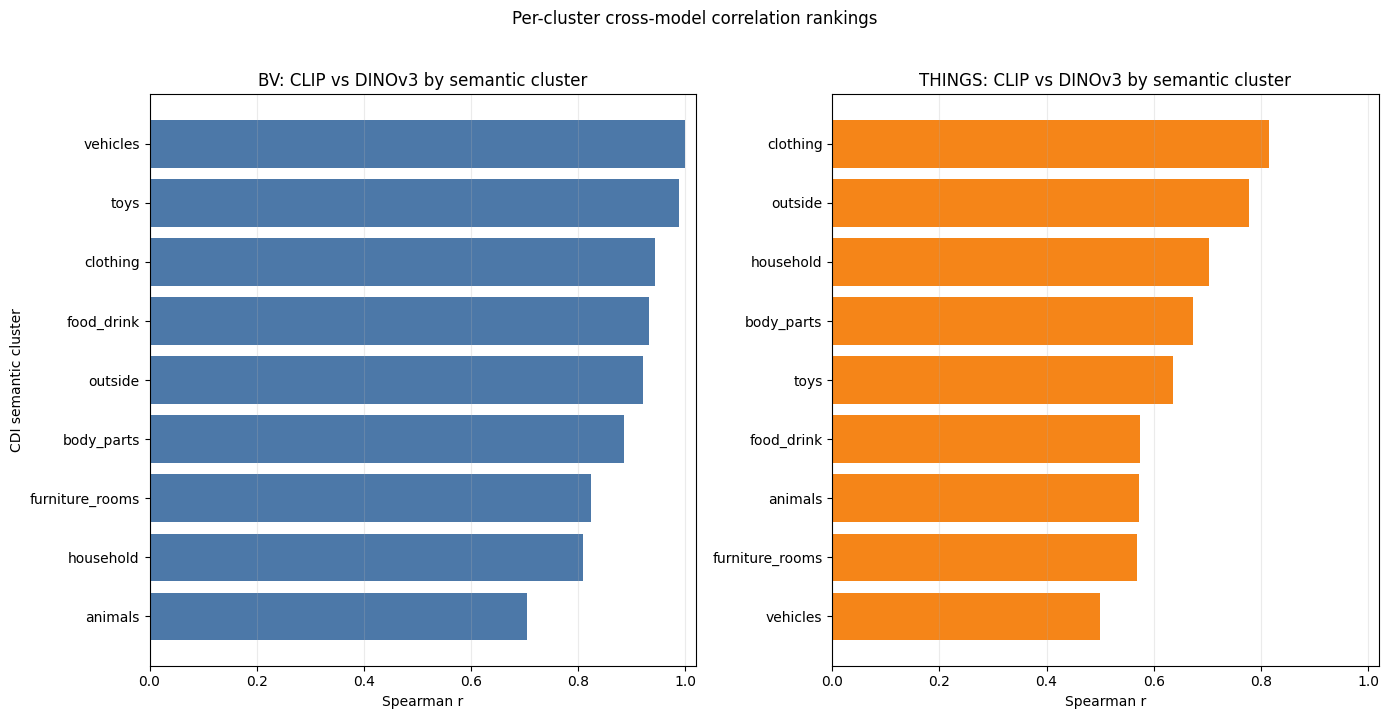

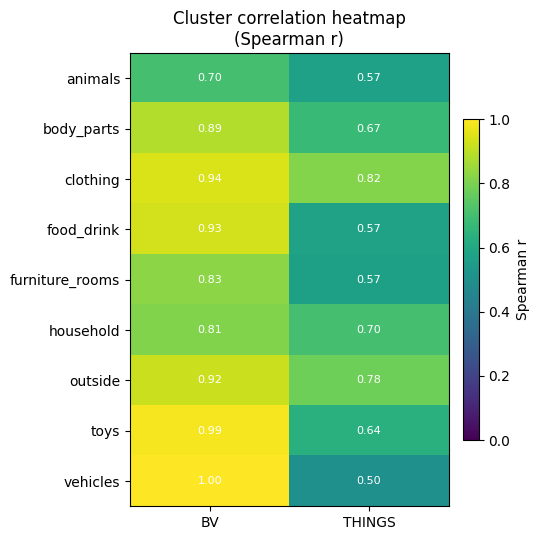

Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/figures/bv_things_cross_model_cluster_rankings_filtered-0.27.png
Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/figures/bv_things_cross_model_cluster_rankings_filtered-0.27.pdf
Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/figures/bv_things_cross_model_cluster_heatmap_filtered-0.27.png
Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/figures/bv_things_cross_model_cluster_heatmap_filtered-0.27.pdf


In [11]:
# If needed, load per-cluster results from disk.
if "cluster_corr_df" not in globals():
    cluster_corr_csv = RESULTS_DIR / f"bv_things_cross_model_cluster_correlations_filtered-{THRESHOLD_TOKEN}.csv"
    if not cluster_corr_csv.exists():
        raise FileNotFoundError(f"Missing cluster correlation CSV: {cluster_corr_csv}")
    cluster_corr_df = pd.read_csv(cluster_corr_csv)

# Keep semantic order for consistent colors/order fallback.
sem_rank = {s: i for i, s in enumerate(CDI_SEMANTIC_ORDER)}
plot_df = cluster_corr_df.copy()
plot_df["rank_bv"] = plot_df["bv_spearman_r"].rank(ascending=False, method="min")
plot_df["rank_things"] = plot_df["things_spearman_r"].rank(ascending=False, method="min")

# --------------------------
# Figure 1: ranked bar plots
# --------------------------
bv_sorted = plot_df.sort_values("bv_spearman_r", ascending=True)
th_sorted = plot_df.sort_values("things_spearman_r", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharex=True)

axes[0].barh(bv_sorted["semantic_cluster"], bv_sorted["bv_spearman_r"], color="#4C78A8")
axes[0].set_title("BV: CLIP vs DINOv3 by semantic cluster")
axes[0].set_xlabel("Spearman r")
axes[0].set_ylabel("CDI semantic cluster")
axes[0].grid(axis="x", alpha=0.25)

axes[1].barh(th_sorted["semantic_cluster"], th_sorted["things_spearman_r"], color="#F58518")
axes[1].set_title("THINGS: CLIP vs DINOv3 by semantic cluster")
axes[1].set_xlabel("Spearman r")
axes[1].set_ylabel("")
axes[1].grid(axis="x", alpha=0.25)

for ax in axes:
    ax.set_xlim(0, 1.02)

fig.suptitle("Per-cluster cross-model correlation rankings", y=1.02)
fig.tight_layout()

rank_png = FIGURES_DIR / f"bv_things_cross_model_cluster_rankings_filtered-{THRESHOLD_TOKEN}.png"
rank_pdf = FIGURES_DIR / f"bv_things_cross_model_cluster_rankings_filtered-{THRESHOLD_TOKEN}.pdf"
fig.savefig(rank_png, dpi=220, bbox_inches="tight")
fig.savefig(rank_pdf, bbox_inches="tight")
plt.show()
plt.close(fig)

# --------------------------------
# Figure 2: compact heatmap summary
# --------------------------------
heat_df = (
    plot_df[["semantic_cluster", "bv_spearman_r", "things_spearman_r"]]
    .set_index("semantic_cluster")
    .reindex(sorted(plot_df["semantic_cluster"], key=lambda s: sem_rank.get(s, 999)))
)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
im = ax.imshow(heat_df.values, cmap="viridis", aspect="auto", vmin=0, vmax=1)
ax.set_xticks([0, 1])
ax.set_xticklabels(["BV", "THINGS"])
ax.set_yticks(np.arange(len(heat_df.index)))
ax.set_yticklabels(heat_df.index)
ax.set_title("Cluster correlation heatmap\n(Spearman r)")

for i in range(heat_df.shape[0]):
    for j in range(heat_df.shape[1]):
        v = heat_df.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", color="white", fontsize=8)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Spearman r")
fig.tight_layout()

heat_png = FIGURES_DIR / f"bv_things_cross_model_cluster_heatmap_filtered-{THRESHOLD_TOKEN}.png"
heat_pdf = FIGURES_DIR / f"bv_things_cross_model_cluster_heatmap_filtered-{THRESHOLD_TOKEN}.pdf"
fig.savefig(heat_png, dpi=220, bbox_inches="tight")
fig.savefig(heat_pdf, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved: {rank_png}")
print(f"Saved: {rank_pdf}")
print(f"Saved: {heat_png}")
print(f"Saved: {heat_pdf}")